# 🌸 CodeAlpha Data Science Internship — Task 1: Iris Flower Classification

**Goal:** Train a machine learning model that classifies an Iris flower as *setosa*, *versicolor* or *virginica* from its four measurements (sepal length/width, petal length/width).

**Dataset:** [Iris CSV on Kaggle](https://www.kaggle.com/datasets/saurabh00007/iriscsv) (150 rows, 3 balanced classes).

**Steps in this notebook**
1. Import libraries
2. Load the data
3. Explore the data (EDA)
4. Visualize
5. Prepare data (features/target, train-test split, scaling)
6. Train and compare several models
7. Evaluate the best model on unseen test data
8. Predict on new flowers
9. Conclusion

## 1. Import libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


## 2. Load the dataset
Download `Iris.csv` from the Kaggle link and place it in the **same folder as this notebook**.
If the file is not found, the cell falls back to the same Iris data bundled with Scikit-learn, converted to the Kaggle column format, so the notebook always runs.

In [2]:
if os.path.exists("Iris.csv"):
    df = pd.read_csv("Iris.csv")
    print("Loaded Iris.csv from Kaggle")
else:
    from sklearn.datasets import load_iris
    raw = load_iris(as_frame=True)
    df = raw.frame.copy()
    df.columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "target"]
    df["Species"] = df["target"].map(dict(enumerate(["Iris-setosa", "Iris-versicolor", "Iris-virginica"])))
    df.insert(0, "Id", range(1, len(df) + 1))
    df = df.drop(columns="target")
    print("Iris.csv not found -> loaded the identical Iris dataset from Scikit-learn")

print("Shape:", df.shape)
df.head()

Iris.csv not found -> loaded the identical Iris dataset from Scikit-learn
Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Explore the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.057333,3.758000,1.199333
std,43.445368,0.828066,0.435866,1.765298,0.762238
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows (ignoring Id):", df.drop(columns="Id").duplicated().sum())
print("\nClass distribution:")
print(df["Species"].value_counts())

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows (ignoring Id): 1

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


The dataset has **no missing values** and the three classes are perfectly balanced (50 each), so plain accuracy is a fair metric.

## 4. Visualize

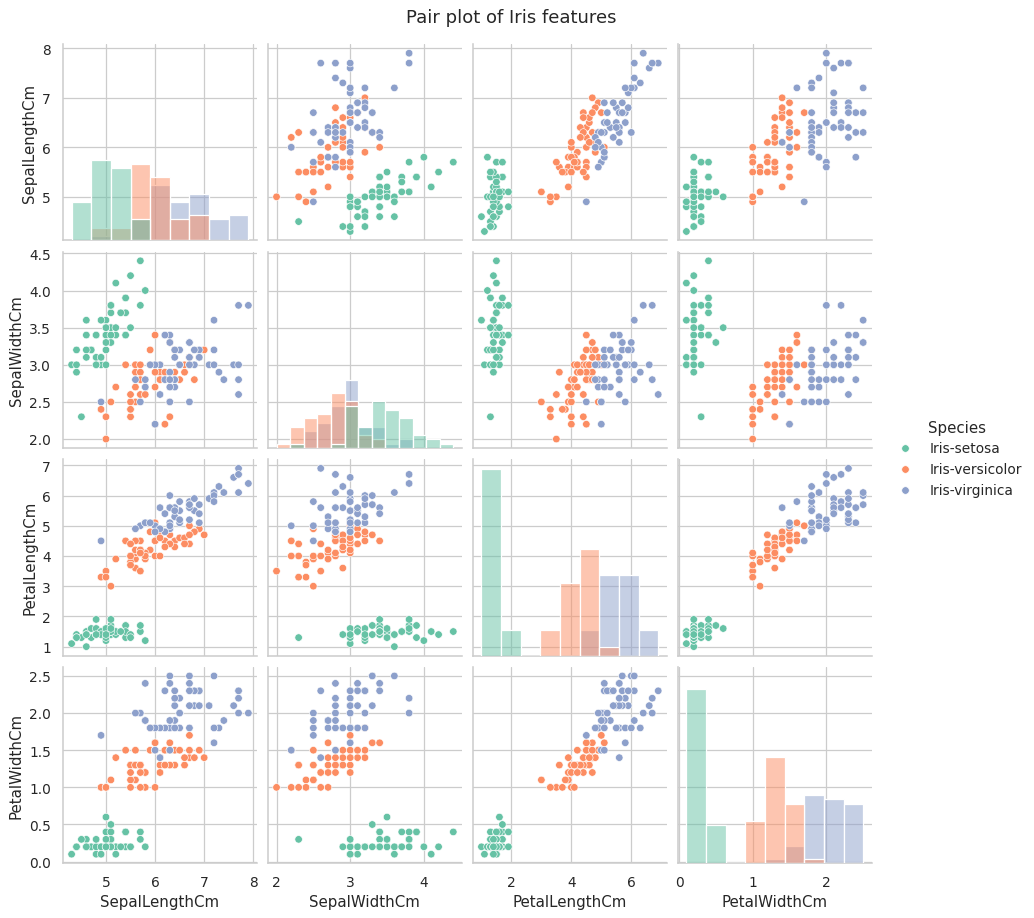

In [6]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
sns.pairplot(df.drop(columns="Id"), hue="Species", diag_kind="hist", palette="Set2")
plt.suptitle("Pair plot of Iris features", y=1.02)
plt.show()

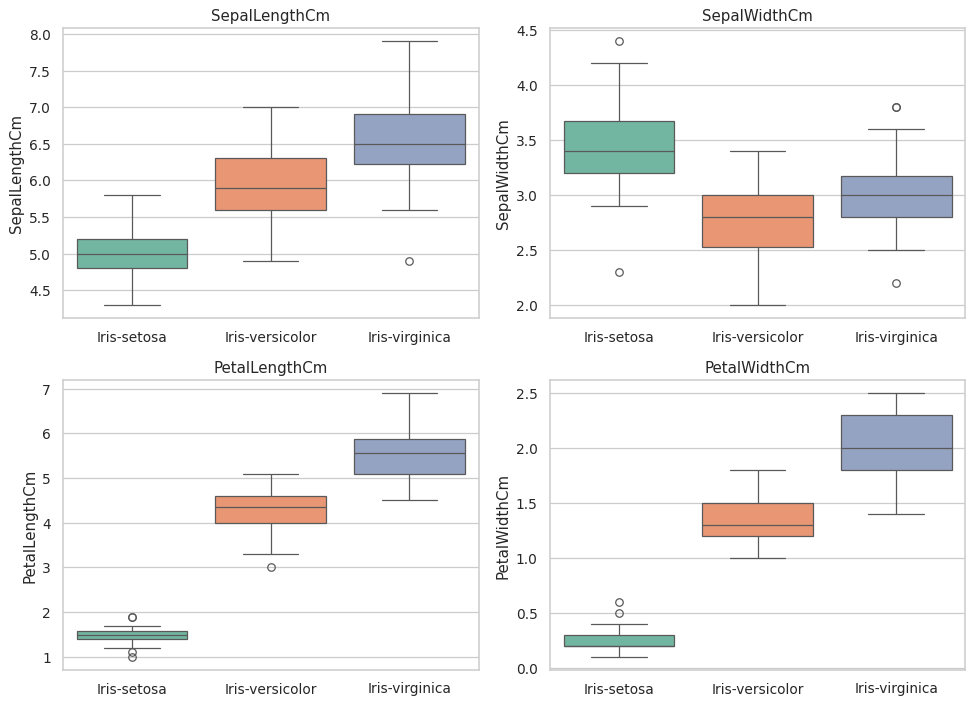

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="Species", y=col, palette="Set2", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

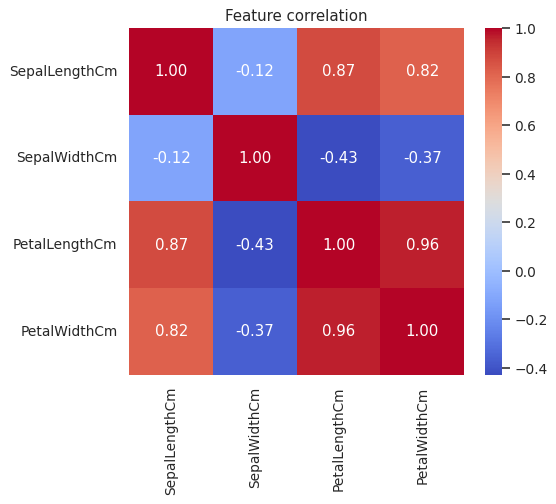

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature correlation")
plt.show()

**Observations**
- *Setosa* is clearly separated from the other two species, especially by petal length and petal width.
- *Versicolor* and *virginica* overlap slightly, which is where a model may make its few mistakes.
- Petal length and petal width are strongly correlated and are the most useful features.

## 5. Prepare the data

In [9]:
X = df[features]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("\nTest class counts:")
print(y_test.value_counts())

Training samples: 120
Testing samples : 30

Test class counts:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


`stratify=y` keeps the same class proportions in the train and test sets. Scaling is done inside a pipeline so it is learned from training data only (no data leakage).

## 6. Train and compare models

In [10]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=200)),
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=42)),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv)
    rows.append({"Model": name, "Test Accuracy": test_acc,
                 "CV Mean Accuracy": cv_scores.mean(), "CV Std": cv_scores.std()})

results = pd.DataFrame(rows).sort_values("CV Mean Accuracy", ascending=False).reset_index(drop=True)
results.round(4)

,Model,Test Accuracy,CV Mean Accuracy,CV Std
0,SVM (RBF),0.9667,0.9667,0.0167
1,Logistic Regression,0.9333,0.9583,0.0264
2,K-Nearest Neighbors,0.9333,0.9583,0.0264
3,Decision Tree,0.9333,0.9500,0.0167
4,Random Forest,0.9000,0.9500,0.0312


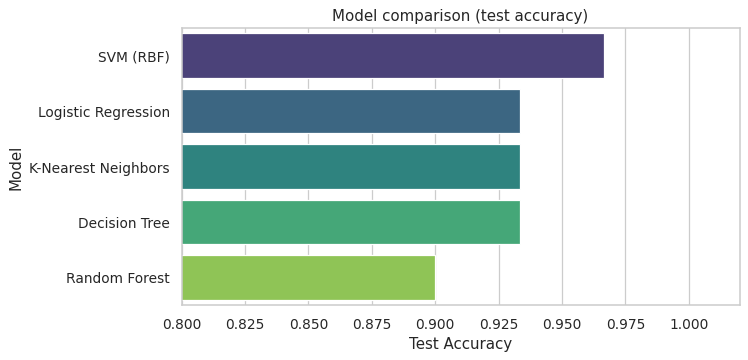

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="Test Accuracy", y="Model", palette="viridis")
plt.xlim(0.8, 1.02)
plt.title("Model comparison (test accuracy)")
plt.show()

## 7. Evaluate the best model on the test set

In [12]:
best_name = results.loc[0, "Model"]
best_model = models[best_name]
y_pred = best_model.predict(X_test)

print("Best model (by cross-validation):", best_name)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Best model (by cross-validation): SVM (RBF)
Test accuracy: 0.9667

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



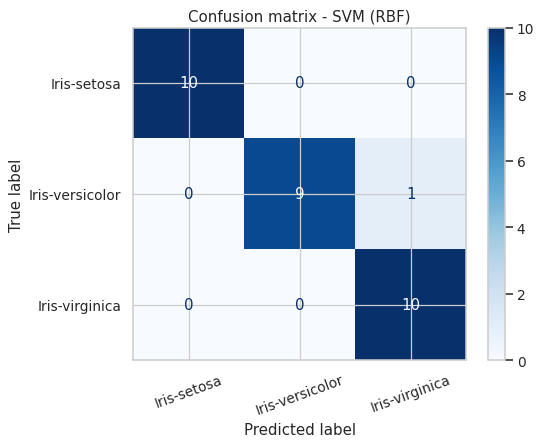

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(cmap="Blues", xticks_rotation=20)
plt.title(f"Confusion matrix - {best_name}")
plt.show()

## 8. Predict new flowers

In [14]:
new_flowers = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2],
     [6.0, 2.9, 4.5, 1.5],
     [6.9, 3.1, 5.8, 2.3]],
    columns=features,
)
new_flowers["Predicted Species"] = best_model.predict(new_flowers[features])
new_flowers

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicted Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,6.0,2.9,4.5,1.5,Iris-versicolor
2,6.9,3.1,5.8,2.3,Iris-virginica


## 9. Conclusion
- Iris data is clean and balanced, so little preprocessing was needed.
- Several algorithms reach roughly **90-97%** test accuracy; the best model was chosen using 5-fold cross-validation rather than a single split.
- *Setosa* is classified perfectly; the only errors are between *versicolor* and *virginica*.
- Petal measurements are the strongest predictors of species.

**Concepts practiced:** supervised classification, train/test split, stratification, feature scaling, cross-validation, accuracy, precision/recall/F1 and the confusion matrix.